In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

start_date = "2024-01-01"

gold = yf.download("GC=F", start=start_date, auto_adjust=False, progress=False)
silver = yf.download("SI=F", start=start_date, auto_adjust=False, progress=False)

In [8]:
gold = yf.download("GC=F", start="2024-01-01", auto_adjust=False, progress=False)
silver = yf.download("SI=F", start="2024-01-01", auto_adjust=False, progress=False)

# Flatten columns if needed
gold.columns = [col[0] if isinstance(col, tuple) else col for col in gold.columns]
silver.columns = [col[0] if isinstance(col, tuple) else col for col in silver.columns]

gold_close = gold["Close"].squeeze().rename("gold_close")
silver_close = silver["Close"].squeeze().rename("silver_close")

df = pd.concat([gold_close, silver_close], axis=1).dropna().copy()
df["gold_silver_ratio"] = df["gold_close"] / df["silver_close"]

df.tail()

,gold_close,silver_close,gold_silver_ratio
Date,,,
2026-04-23,4705.100098,75.464996,62.348113
2026-04-24,4722.299805,76.383003,61.823961
2026-04-27,4675.399902,75.002998,62.336173
2026-04-28,4591.500000,73.205002,62.721124
2026-04-29,4574.299805,73.055000,62.614466


In [9]:
window = 20

df["ratio_mean_20"] = df["gold_silver_ratio"].rolling(window).mean()
df["ratio_std_20"] = df["gold_silver_ratio"].rolling(window).std()
df["ratio_zscore_20"] = (
    (df["gold_silver_ratio"] - df["ratio_mean_20"]) / df["ratio_std_20"]
)

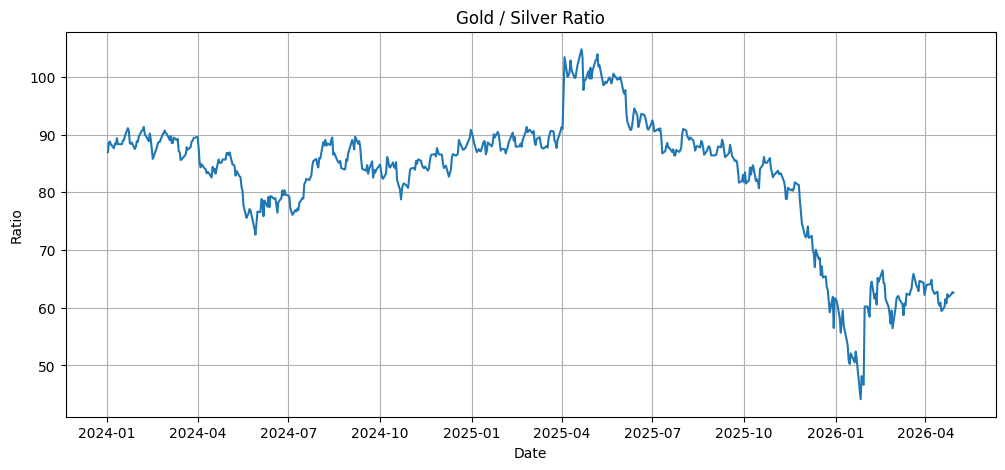

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["gold_silver_ratio"])
plt.title("Gold / Silver Ratio")
plt.xlabel("Date")
plt.ylabel("Ratio")
plt.grid(True)
plt.show()

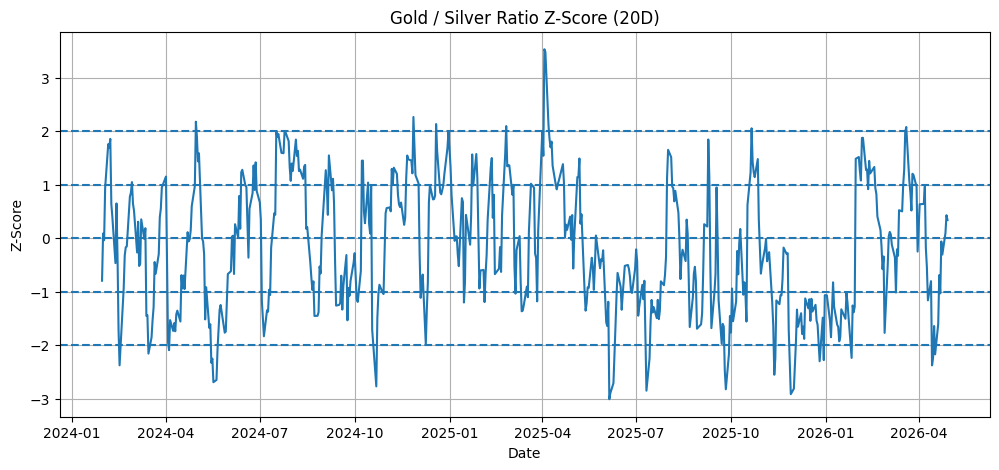

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["ratio_zscore_20"])
plt.axhline(0, linestyle="--")
plt.axhline(1, linestyle="--")
plt.axhline(-1, linestyle="--")
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.title("Gold / Silver Ratio Z-Score (20D)")
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.grid(True)
plt.show()

In [12]:
latest = df.iloc[-1]

print("Latest gold close:", round(latest["gold_close"], 4))
print("Latest silver close:", round(latest["silver_close"], 4))
print("Latest gold/silver ratio:", round(latest["gold_silver_ratio"], 4))
print("Latest 20D z-score:", round(latest["ratio_zscore_20"], 4))

Latest gold close: 4574.2998
Latest silver close: 73.055
Latest gold/silver ratio: 62.6145
Latest 20D z-score: 0.3364


In [13]:
if latest["ratio_zscore_20"] > 1:
    print("Gold looks rich versus silver on a short-term basis.")
elif latest["ratio_zscore_20"] < -1:
    print("Silver looks rich versus gold on a short-term basis.")
else:
    print("The ratio is not especially stretched on a short-term basis.")

The ratio is not especially stretched on a short-term basis.


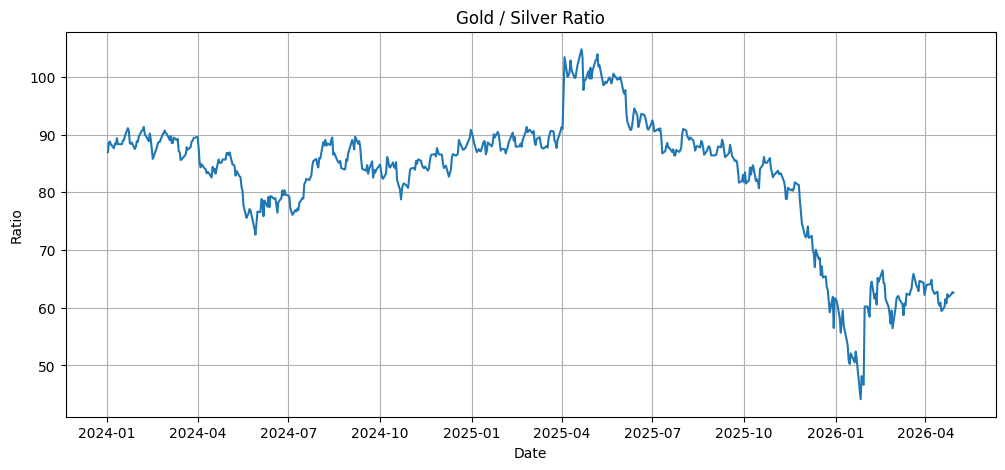

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["gold_silver_ratio"])
plt.title("Gold / Silver Ratio")
plt.xlabel("Date")
plt.ylabel("Ratio")
plt.grid(True)
plt.savefig("../outputs/charts/gold_silver_ratio.png", bbox_inches="tight")
plt.show()

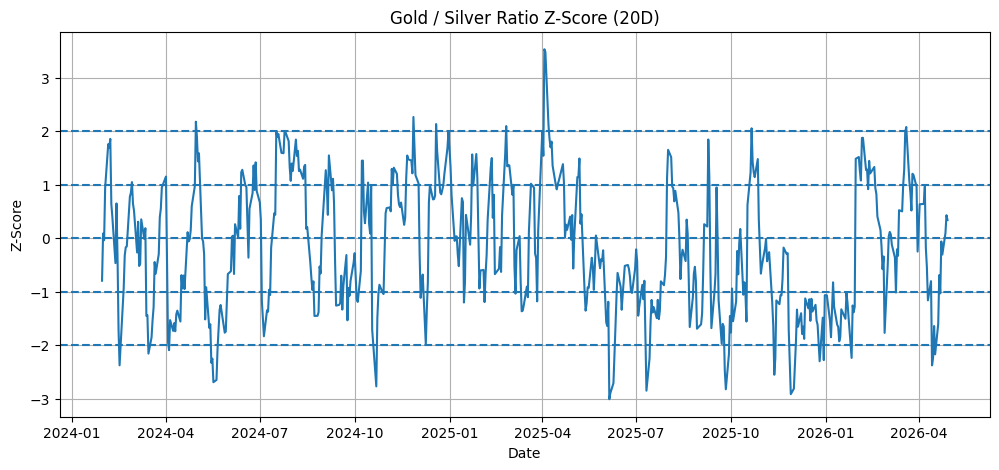

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["ratio_zscore_20"])
plt.axhline(0, linestyle="--")
plt.axhline(1, linestyle="--")
plt.axhline(-1, linestyle="--")
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.title("Gold / Silver Ratio Z-Score (20D)")
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.grid(True)
plt.savefig("../outputs/charts/gold_silver_ratio_zscore.png", bbox_inches="tight")
plt.show()

In [16]:
for window in [20, 60, 120]:
    df[f"ratio_mean_{window}"] = df["gold_silver_ratio"].rolling(window).mean()
    df[f"ratio_std_{window}"] = df["gold_silver_ratio"].rolling(window).std()
    df[f"ratio_zscore_{window}"] = (
        (df["gold_silver_ratio"] - df[f"ratio_mean_{window}"]) / df[f"ratio_std_{window}"]
    )

In [17]:
latest = df.iloc[-1]

print("Latest gold/silver ratio:", round(latest["gold_silver_ratio"], 4))
print("20D z-score:", round(latest["ratio_zscore_20"], 4))
print("60D z-score:", round(latest["ratio_zscore_60"], 4))
print("120D z-score:", round(latest["ratio_zscore_120"], 4))

Latest gold/silver ratio: 62.6145
20D z-score: 0.3364
60D z-score: 0.2417
120D z-score: -0.1762


In [18]:
df["gold_ret"] = df["gold_close"].pct_change()
df["silver_ret"] = df["silver_close"].pct_change()
df["rolling_corr_20"] = df["gold_ret"].rolling(20).corr(df["silver_ret"])

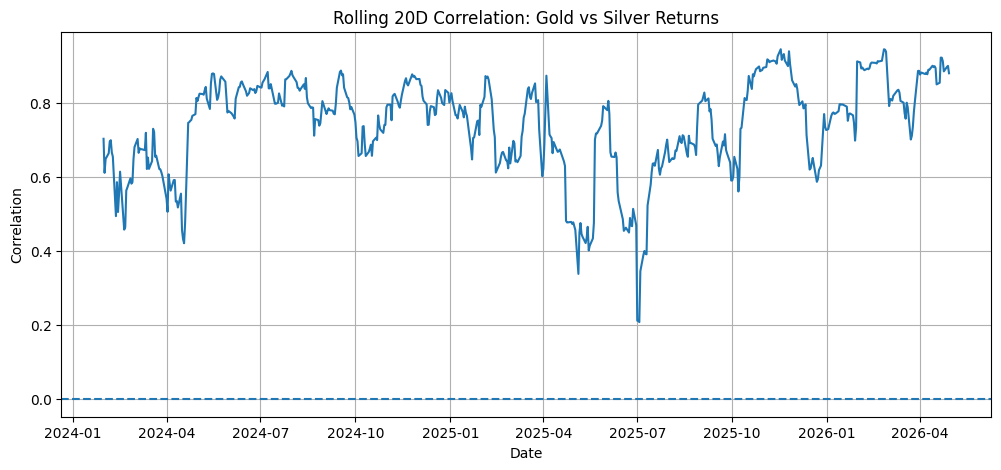

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["rolling_corr_20"])
plt.axhline(0, linestyle="--")
plt.title("Rolling 20D Correlation: Gold vs Silver Returns")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.grid(True)
plt.show()

In [20]:
beta = df[["gold_ret", "silver_ret"]].dropna().cov().iloc[0, 1] / df["silver_ret"].dropna().var()
print("Approximate hedge ratio (gold vs silver):", round(beta, 4))

Approximate hedge ratio (gold vs silver): 0.3549


In [21]:
current_ratio = latest["gold_silver_ratio"]
percentile = (df["gold_silver_ratio"] < current_ratio).mean() * 100
print("Current ratio percentile:", round(percentile, 2), "%")

Current ratio percentile: 10.09 %


## Preliminary pre-trade conclusion

This notebook suggests whether the current gold/silver ratio is statistically stretched on short-, medium-, and longer-term horizons. The key decision variables are:

- whether the ratio z-score is significantly positive or negative
- whether the current ratio sits at an extreme percentile
- whether gold and silver remain sufficiently correlated for a relative-value trade to make sense
- whether the current macro regime supports gold outperforming silver or vice versa

A trade would be more attractive if:
- the ratio is meaningfully stretched
- rolling correlation remains reasonably high
- the macro backdrop supports continuation or mean reversion, depending on the setup

In [22]:
signals = {
    "20D_zscore": latest["ratio_zscore_20"],
    "60D_zscore": latest["ratio_zscore_60"],
    "120D_zscore": latest["ratio_zscore_120"],
    "percentile": percentile,
    "rolling_corr_20": df["rolling_corr_20"].dropna().iloc[-1]
}

signals

{'20D_zscore': np.float64(0.33637831204362184),
 '60D_zscore': np.float64(0.2417337965686859),
 '120D_zscore': np.float64(-0.17619490776426497),
 'percentile': np.float64(10.085470085470085),
 'rolling_corr_20': np.float64(0.8805252133443776)}